In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/student-marks-dataset/Student_Marks.csv


## 1. Import the necessary library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [3]:
# Loading Student Marks data
df = pd.read_csv ("/kaggle/input/datasets/yasserh/student-marks-dataset/Student_Marks.csv")
df

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


## 3. Dataset information


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [5]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [6]:
df.tail()

,number_courses,time_study,Marks
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027
99,3,6.335,32.357


## 4. Data Cleaning

In [7]:
df.isnull().sum()

number_courses    0
time_study        0
Marks             0
dtype: int64

## 5.Summary of Statistics

In [8]:
df.describe(include='all')

,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


## 5. Correlation Heatmap

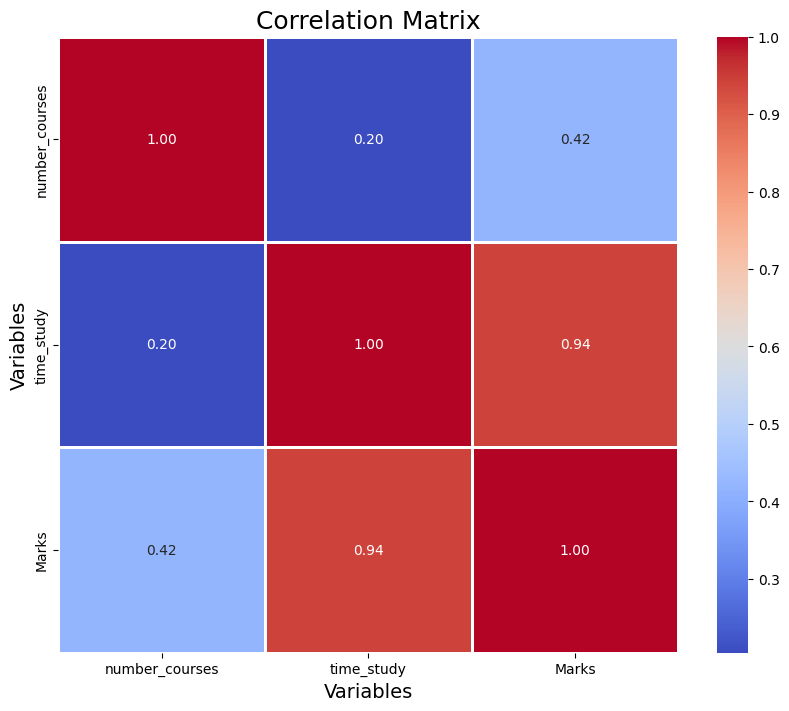

In [9]:
# compute correlation matrix 
corr_matrix = df.corr()

# Visualization 
plt.figure(figsize =(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidth = 2, cbar = True, annot=True, fmt='.2f')

plt.title("Correlation Matrix",fontsize=18)
plt.xlabel('Variables',fontsize=14)
plt.ylabel('Variables',fontsize=14)

plt.show()

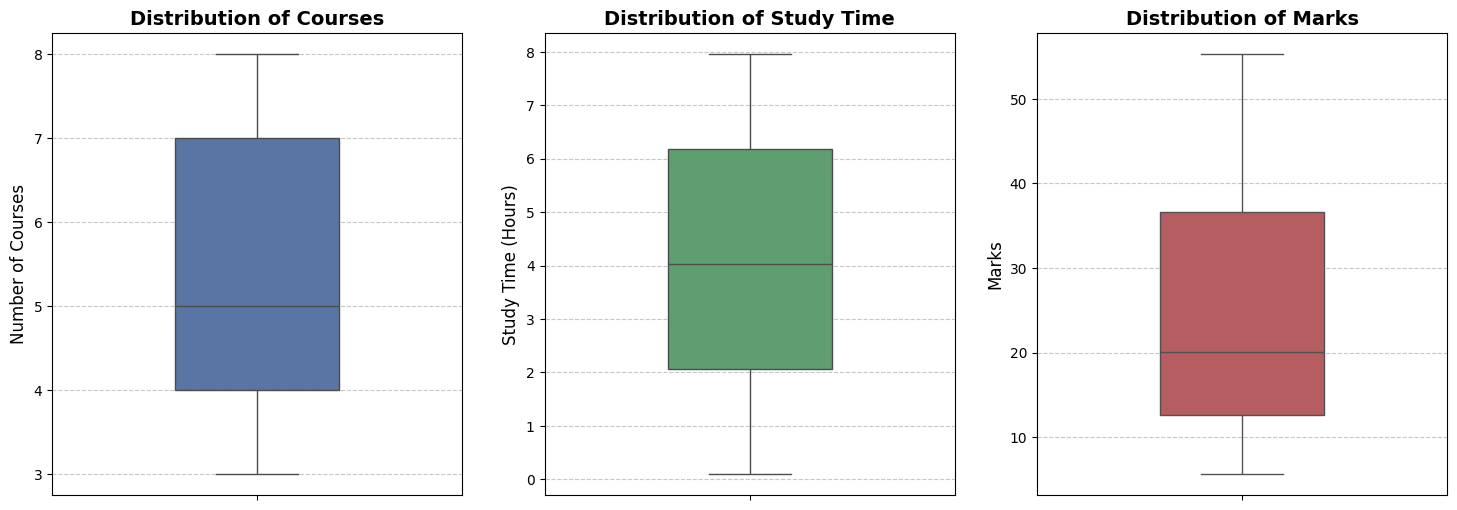

In [10]:
# Visualization 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=df["number_courses"], ax=axes[0], color="#4C72B0", width=0.4)
axes[0].set_title('Distribution of Courses', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Courses', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.boxplot(y=df["time_study"], ax=axes[1], color="#55A868", width=0.4)
axes[1].set_title('Distribution of Study Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Study Time (Hours)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.boxplot(y=df["Marks"], ax=axes[2], color="#C44E52", width=0.4)
axes[2].set_title('Distribution of Marks', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Marks', fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

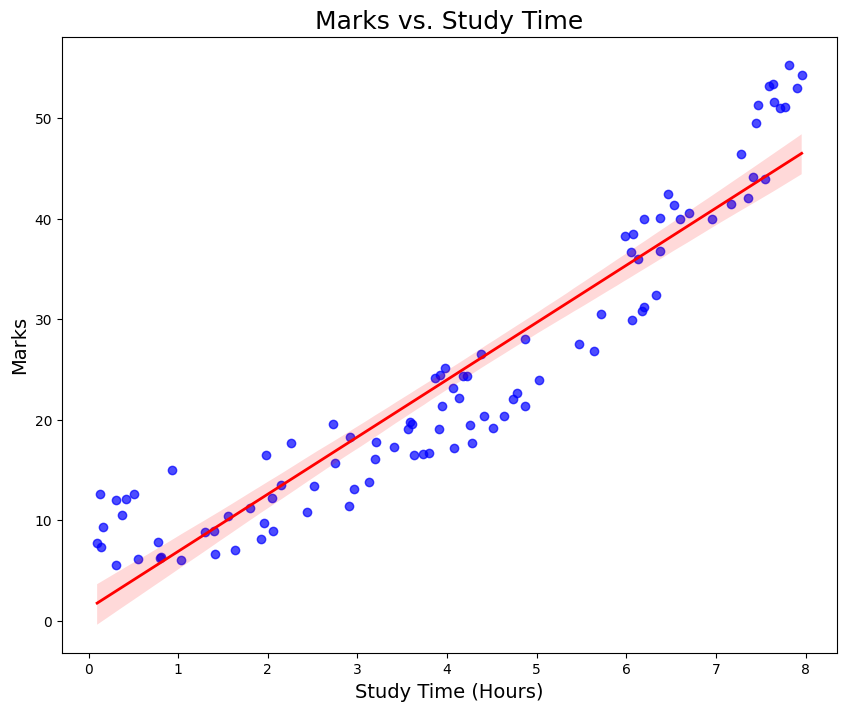

In [11]:
# Visualization 
plt.figure(figsize =(10,8))

sns.regplot(x='time_study', y='Marks', data=df, scatter_kws={'color': 'blue', 'alpha': 0.7},line_kws={'color': 'red', 'linewidth': 2})


plt.title("Marks vs. Study Time",fontsize=18)
plt.xlabel('Study Time (Hours)',fontsize=14)
plt.ylabel('Marks',fontsize=14)

plt.show()

## 6. Splitting Data

In [12]:
x = df[['time_study','number_courses']]
y = df['Marks']

In [13]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)



x = df[["number_courses"]].to_numpy() 
y = df["time_study"].to_numpy().reshape(-1, 1) 


## 7. Linear Regression - Manually

In [14]:
np.random.seed(42)
w = np.random.rand()
b = np.random.rand()

eta = 0.01
epochs = 1000
costval = np.zeros(epochs)

In [15]:
for i in range(epochs):

    yhat = (w * x) + b
    w = w - eta * (x.T @ (yhat - y))/ len(x)
    b = b - eta * np.mean((yhat - y))
    costval[i] = 0.5 * np.mean((yhat - y)**2)
    
    if costval[i] < 1e-5:
        break



In [16]:
print("                 Final Calculation")
print("-"*60)
print(f"Weight = {w}")
print(f"Bais = {b}")
print(f"Error = {costval[i]}")


                 Final Calculation
------------------------------------------------------------
Weight = [[0.37451072]]
Bais = 2.0346824376922985
Error = 2.689640399186626


## 8. Linear Regressiom - Function

In [17]:
lr = LinearRegression()

In [18]:
model = lr.fit(x_train, y_train)

In [19]:
y_pred = model.predict(x_test)

In [20]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

In [21]:
print(f"R2 Score (Accuracy): {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R2 Score (Accuracy): 0.9460 (94.60%)
Mean Squared Error (MSE): 14.2007
Mean Absolute Error (MAE): 3.0793


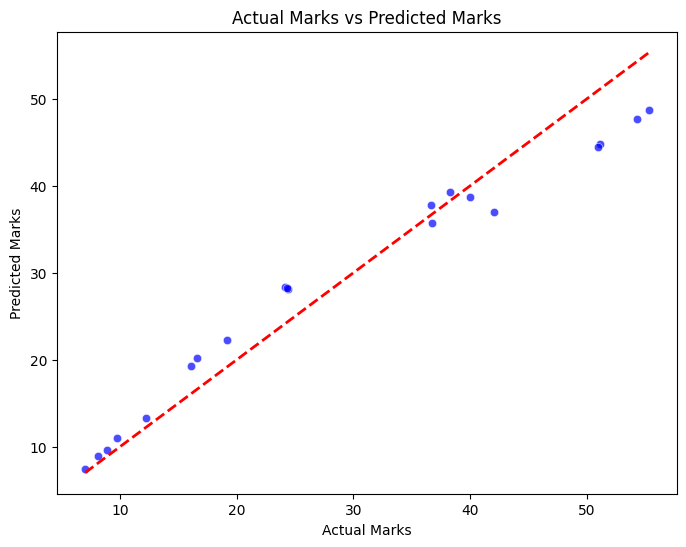

In [22]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)

plt.title('Actual Marks vs Predicted Marks')
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')

plt.show()

## 9. Prediction Student Degree

In [23]:
def predict_student_marks(number_courses, time_study):

    features = [[number_courses , time_study]]
    
    predicted_mark = model.predict(features)[0]
    
    print("============== Prediction ===============")
    print(f"Number of courses: {number_courses}")
    print(f"Time Study per Hour: {time_study}")
    print(f"Predicted Degree: {predicted_mark}")
    
    return predicted_mark


test_prediction = predict_student_marks(number_courses=4, time_study=6.5)

============== Prediction ===============
Number of courses: 4
Time Study per Hour: 6.5
Predicted Degree: 26.23151457279626
